In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import json
import numpy as np

In [46]:
path = "data_reddit_query"
dfs = []
for filename in os.listdir(path):
    with open(os.path.join(path, filename), "r", encoding="utf-8") as file:
        data = json.load(file)
        try:
            data = data["data"]
            data = data["children"]
            df = pd.json_normalize(data)
            dfs.append(df)
        except:
            pass

df = pd.concat(dfs, ignore_index=True)

/tmp/ipykernel_58894/2829386436.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dfs, ignore_index=True)


In [52]:
in_favor_keywords = ["support", "agree", "yes", "pro"]
against_keywords = ["oppose", "no", "disagree", "against", "stopped", "ban", "block"]

def classify_text(text):
    if not isinstance(text, str):
        return np.nan  # Handle non-string values (e.g., NaN or missing data)
    text_lower = text.lower()
    in_favor_count = sum(keyword in text_lower for keyword in in_favor_keywords)
    against_count = sum(keyword in text_lower for keyword in against_keywords)
    if in_favor_count > against_count:
        return 1
    elif against_count > in_favor_count:
        return 0

In [48]:
df1 = df
df1['text'] = df['data.title'] + ',' + df['data.selftext']
df1["favor_classification"] = df1["text"].apply(classify_text)

/tmp/ipykernel_58894/1294127723.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1['text'] = df['data.title'] + ',' + df['data.selftext']
/tmp/ipykernel_58894/1294127723.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1["favor_classification"] = df1["text"].apply(classify_text)


In [124]:
df1

,kind,data.approved_at_utc,data.subreddit,data.selftext,data.author_fullname,data.saved,data.mod_reason_title,data.gilded,data.clicked,data.title,...,data.media_metadata.kgwm2bxfbwqf1.status,data.media_metadata.kgwm2bxfbwqf1.e,data.media_metadata.kgwm2bxfbwqf1.m,data.media_metadata.kgwm2bxfbwqf1.p,data.media_metadata.kgwm2bxfbwqf1.s.y,data.media_metadata.kgwm2bxfbwqf1.s.x,data.media_metadata.kgwm2bxfbwqf1.s.u,data.media_metadata.kgwm2bxfbwqf1.id,text,favor_classification
3,t3,None,Slovenia,Več info: https://fightchatcontrol.eu/,t2_am3ptzg0,False,None,0.0,False,EU želi odobriti ‘chat control’ zakon (CSAM re...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EU želi odobriti ‘chat control’ zakon (CSAM re...,1.0
7,t3,None,Denmark,Ifølge tidligere EMP Patrick Breyer er Tysklan...,t2_1tv7zika84,False,None,0.0,False,"ChatKontrol er dødsdømt, Tyskland er ude!!",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"ChatKontrol er dødsdømt, Tyskland er ude!!,Ifø...",1.0
8,t3,None,Denmark,"Hey r/Denmark,\n\nI'm fucking angry and you sh...",t2_hdlcyxaao,False,None,0.0,False,Danish MEPs are voting to scan ALL your privat...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Danish MEPs are voting to scan ALL your privat...,0.0
9,t3,None,Denmark,Der er ikke længere flertal for chatkontrol i ...,t2_1p00z45txg,False,None,0.0,False,Chatkontrol aflyst,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Chatkontrol aflyst,Der er ikke længere flertal...",1.0
13,t3,None,Denmark,https://disobey.net/@yawnbox/11520336548552936...,t2_5g2jc9ml,False,None,0.0,False,Denmark is moving forward with 'chat control' ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Denmark is moving forward with 'chat control' ...,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926,t3,None,portugal,,t2_12oua0j7ds,False,None,0.0,False,[Parlamento] Rejeição da Proposta de Regulamen...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[Parlamento] Rejeição da Proposta de Regulamen...,1.0
930,t3,None,portugal,Sou só eu que ainda não vi isto ser reportado ...,t2_xu7ub,False,None,0.0,False,EU Countries' Stances on Chat Control as of Ea...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EU Countries' Stances on Chat Control as of Ea...,0.0
932,t3,None,portugal,,t2_vl26gn3s,False,None,0.0,False,Chat Control Is Back on the Menu in the EU. It...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chat Control Is Back on the Menu in the EU. It...,0.0
933,t3,None,portugal,Pode dar jeito para explicar a outras pessoa d...,t2_yvz7m,False,None,0.0,False,Video em português a explicar o ChatControl,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Video em português a explicar o ChatControl,Po...",0.0


In [50]:
df1.dtypes

kind                                      object
data.approved_at_utc                      object
data.subreddit                            object
data.selftext                             object
data.author_fullname                      object
                                          ...   
data.media_metadata.kgwm2bxfbwqf1.s.x    float64
data.media_metadata.kgwm2bxfbwqf1.s.u     object
data.media_metadata.kgwm2bxfbwqf1.id      object
text                                      object
favor_classification                      object
Length: 909, dtype: object

In [ ]:
# Replace 'Unknown' with NaN
df1["favor_classification"] = df1["favor_classification"].replace('Unknown', np.nan)

# Convert the column to float
df1["favor_classification"] = pd.to_numeric(df1["favor_classification"], errors='coerce')
df1 = df1.dropna(subset=['favor_classification'])
df1 = df1.astype({'favor_classification': float})
df1["favor_classification"].mean()



/tmp/ipykernel_58894/1230712111.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1["favor_classification"] = df1["favor_classification"].replace('Unknown', np.nan)


np.float64(0.3675)

In [126]:
def favor_score(y,x,labels):
    y_value = y
    x_value = x


    plt.axvline(x=0.5, linestyle='-', color='blue', label='Neutral Line (0.5)')

    for y_,x_, label in zip(y_value, x_value, labels):
        plt.plot(x_, y_, marker='o', markersize=8, color='red', label=label)
        plt.text(x_, y_+(y_*0.005), ' ' + label, verticalalignment='center_baseline', fontsize=10)


    # Customize the plot
    plt.xlabel("Proportion in Favor")
    plt.ylabel("Number of datapoints")
    plt.xlim(0, 1)
    plt.title("Sentiment on Chat Control")
    plt.grid(True)
    #plt.legend()
    plt.show()

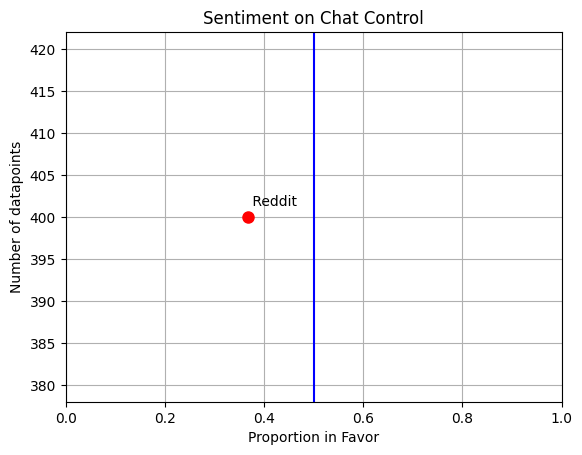

In [127]:
favor_score([len(df1)], [df1["favor_classification"].mean()], ["Reddit"])